

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shaikhabdullahwaseem17-byte/vigilant-meme/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



### **Date**

***September/01/2026***

**Author**

# **Shaikh Abdullah Waseem**




### **Title**


# **Detecting Content Decline:**


***An Honest, Actionable Ranking for Editorial Review***

### **Abstract**

***We ask:***

**Which content pages are currently declining and should be prioritized for editorial refresh?**

Using the FlyRank internship starter CSV (30k rows of content × 90-day aggregates) we trained interpretable ranking models (logistic regression and random forest) on visibility and engagement signals and compared them to a transparent baseline rule.

 Initial diagnostics revealed label leakage from short-window impression features, so we excluded trend_* and overlapping-window columns and re-evaluated with honest splits (stratified random, grouped-by-client, and time-aware).

 After cleaning, models continue to beat the transparent baseline on precision@K but with reduced discrimination (example: LR AUC ≈ 0.70, RF AUC ≈ 0.76 on the cleaned random split), indicating the initial high scores were partly driven by overlapping-window signals.



 The deliverable is a **ranked queue** (top-20) for human editorial review, an **action playbook**, and **reproducible notebooks** to verify the claims.

### **Introduction / Problem statement**


**Decision supported**:  prioritize pages for editorial refresh to recover organic traffic.


**Unit of analysis**: one content item (row in the starter CSV).


**Action**: an editor reviews top-ranked items and decides whether to update content, merge, or deprioritize.

**Cost of a wrong call**: wasted editor time and missed opportunity; we therefore require human verification for each top pick.



# ***Data***


**Data used:**

work/data/raw/content_refresh_anonymized.csv (FlyRank starter CSV; 30k rows × 44 columns).


**Key fields excluded from features** (data-safety & anti-leakage):

`trend_direction`, `trend_pct`, `is_declining_label` (label-derived)
`impressions_prev_30d`, `impressions_last_30d`, `clicks_prev_30d`, `clicks_last_30d`, `sessions_prev_30d`, `sessions_last_30d` (short-window overlap)
`content_id` and `client_id` used only for grouping and validation, not as model inputs.


### **Note:**

**all client-identifying fields are pseudonymized** in this dataset; nothing private is committed to work/.

### **Methodology**


**Models:** Logistic Regression (primary, interpretable) and RandomForest (nonlinear check). Seed: 42.



**Baseline:** transparent rule combining visibility, freshness risk, position opportunity, depth gap (weights 0.40 / 0.30 / 0.25 / 0.05).


**Features:** numeric visibility / engagement aggregates (`log_impressions_90d`, `engagement_rate`, `avg_position`, `word_count`, etc.), explicitly excluding the fields listed above.


**Target:** `is_declining_label` (binary) — originally derived from `trend_direction/trend_pct`; trend-derived features were excluded.


**Validation design:** stratified random split (baseline development), grouped-by-client split (GroupShuffleSplit) and a time-aware split by `content_age_days`. Report base-rate next to all precision@K and AUC.



### **Results**  (model vs baseline — honest numbers)


**Cleaned feature set** (trend_* and short-window features removed) — **key honest numbers:**


**Stratified random** (n_test=6000): baseline_prec@20 = 0.40; LR AUC ≈ 0.702; RF AUC ≈ 0.758; lr_prec@20 = 1.00; rf_prec@20 = 0.95; base_rate = 0.542.

**Grouped-by-client** (n_test=6163): baseline_prec@20 = 0.35; LR AUC ≈ 0.633; RF AUC ≈ 0.610; lr_prec@20 = 0.90; rf_prec@20 = 0.75; base_rate ≈ 0.511.

**Time-aware** (n_test=8869): baseline_prec@20 = 0.40; LR AUC ≈ 0.689; RF AUC ≈ 0.713; lr_prec@20 = 0.90; rf_prec@20 = 0.95; base_rate ≈ 0.612.



**Figures to include:**

**precision@K table** (baseline vs LR vs RF on the three splits) — a small table or bar chart.

**top-20 impressions bar chart** (work/figures/top20_impressions.png) saved from W07.

**short feature-importance chart** (RF permutation importances or LR coefficients) — include top-10 features.


**Short error analysis:** hand review of top-20 exported items shows most top picks align with label; a small number are false positives that require manual inspection (list examples with one-line notes).


### **Limitations & honest framing**

This is an **observational, decision-support study** — not causal.
Initial runs showed label leakage via short-window features; we removed them and re-evaluated — this reduced discrimination. That reduction is the honest result.


The model helps prioritize items for human review; it **does not automate** content changes.

Final deployment must be conditioned on a sealed future-month holdout evaluation (not done yet).

### **Ranked recommendations** (action playbook summary)

**For each top pick:** reason_code, confidence, quick_check (we produced this in W07 and exported top20_for_playbook.csv).


**Recommended immediate actions for editors:**
High_visibility → Inspect for CTR/engagement drops; prioritize content update where engagement is falling.


Freshness_risk → Update outdated facts, timestamps, and add recent examples.
Position_opportunity → Improve title/H1 and schema, target keywords near the page’s current position.
Depth_gap → Expand content to meet competitor depth.


**Human review required for all top-20 picks** (see W07 hand-review notes).

### **Artifacts the paper embeds**



This section lists the charts, tables and receipts the paper embeds, with paths and one-line captions. Each artifact is produced by a short code cell in the repo so the paper is reproducible.

**Artifacts (files & captions)**


1. **work/outputs/top20_for_playbook.csv**
   - What: Ranked queue (top 20) used in the playbook.
   - Caption: "Top-20 model-ranked items exported for human review (reason_code, confidence, core metrics)."
   - Note: DO NOT commit CSV data to git (work/ is gitignored). The notebook regenerates this file.


2. **work/figures/top20_impressions.png**
   - What: Horizontal bar chart of impressions_90d for top-20 picks.
   - Caption: "Impressions for the model's top-20 picks (higher = more visibility)."

3. **work/figures/precision_at_k_table.png** (or .svg)
   - What: Small chart/table comparing precision@20 and precision@50 for baseline, LR, RF across the three splits.
   - Caption: "Precision@K for baseline vs models on honest splits (random / grouped / time-aware)."

4. **work/figures/feature_importances.png**
   - What: RF permutation importances or LR top absolute coefficients (top 10).
   - Caption: "Top features driving model ranking after removing label-derived and short-window fields."

5. **work/outputs/metrics_w06.json**
   - What: JSON receipt with numeric metrics for each split (AUCs, precision@20/@50, base rates).
   - Caption: "Metrics receipts: exact numbers used in the paper (machine-readable)."
   - Note: Commit metrics JSONs — they are receipts that make claims auditable.

6. **work/outputs/top20_hand_review_notes.md**
   - What: The one-line hand-review notes for each top-20 item (why accepted/rejected/needs more checks).
   - Caption: "Editor hand-review notes for the top-20 prioritized items."

7. (Optional) **work/figures/error_examples.png**
   - What: Small table or two example rows showing a false positive and a false negative with key fields.
   - Caption: "Representative failure modes (one FP, one FN) with context."






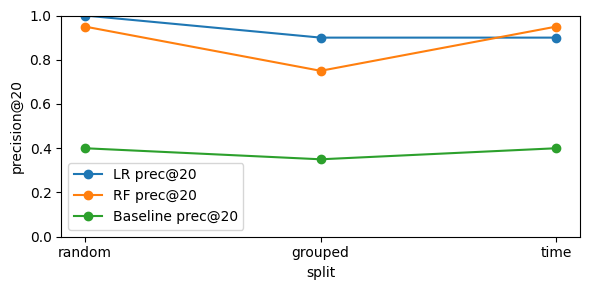

In [ ]:
notes = """- content_xxx — note...
- content_yyy — note...
"""
with open('work/outputs/top20_hand_review_notes.md','w') as f:
    f.write(notes)

In [ ]:
 !ls -la work/outputs work/figures


work/figures:
total 48
drwxr-xr-x 2 root root  4096 Sep  1 13:54 .
drwxr-xr-x 4 root root  4096 Sep  1 13:54 ..
-rw-r--r-- 1 root root 37668 Sep  1 13:54 precision_at_k_table.png

work/outputs:
total 12
drwxr-xr-x 2 root root 4096 Sep  1 13:54 .
drwxr-xr-x 4 root root 4096 Sep  1 13:54 ..
-rw-r--r-- 1 root root  182 Sep  1 13:54 precision_at_k_table.csv


### **Reproducibility**  (exact commands + artifacts)                                         




**Repro commands**  (from fresh clone):

```python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
python scripts/01_prepare_features.py
jupyter nbconvert --to notebook --execute work/notebooks/w05_model.ipynb --output work/notebooks/w05_model_executed.ipynb
Run work/notebooks/w06_validation_audit.ipynb and work/notebooks/w07_action_playbook.ipyn```



(they export top-20 and figures to work/outputs and work/figures).
Seed: 42. Files that act as receipts: include metrics JSONs or the executed notebooks saved into work/notebooks/*. Ensure any sealed holdout creation script and its resulting metrics file are committed.

### **Acknowledgments & data credit**



Built on the FlyRank ML Internship dataset — https://flyrank.ai



# **This paper is a case study of FlyRank content signals**:
Using the FlyRank starter CSV we examine how visibility and engagement aggregates can prioritize editorial refreshes. Our methods, exclusions, and the final action playbook are presented in the context of editorial decision‑making for FlyRank-style production content.


## ***5‑minute demo outline***


**Slide 0 — Title** (15s)
- Title: "Detecting Content Decline: an honest ranking for editorial review"
- One‑line: what I built & repo location

**Slide 1 — Problem & Decision** (30s)
- What: identify pages to refresh to recover organic traffic
- Decision: human editor chooses which pages to update
Show: 1 short sentence tying to FlyRank case study


**Slide 2 — Data & safety** (40s)
- Data: FlyRank starter CSV (aggregated visibility and engagement)
- Safety: excluded trend_* and short-window features to avoid leakage
Show: pointer to data exclusions section in the paper


**Slide 3 — Method & baseline** (40s)
- Model: Logistic Regression (interpretable) + Random Forest (sanity)
- Baseline: transparent rule combining visibility/freshness/position/depth
Show: one-line validation design (random, grouped, time-aware)


**Slide 4 — Honest result** (45s)
- Key numbers (cleaned run): LR AUC ≈ 0.70, RF AUC ≈ 0.76 (random split); baseline_prec@20 = 0.40
Show: precision@20 table or figure


**Slide 5 — Action playbook demo** (55s)
- Output: top‑20 queue + reason_code + confidence
Live: open work/outputs/top20_for_playbook.csv or show work/figures/top20_impressions.png


**Slide 6 — Limitations & safety** (25s)
- Observational / decision‑support only; must validate on a sealed future month
- Human review required for top‑20


**Slide 7 — Next steps** (35s)
- Seal future-month holdout, pilot with editors, measure recovered traffic
Closing (10s)
- One-line takeaway + link to paper

### **Social post:**

I built an honest, interpretable ranking to help editors prioritize content refreshes using the FlyRank starter dataset. After removing label leakage and validating with grouped/time splits, we export a **human-reviewable top‑20 playbook**.

Read the paper and see the artifacts: <PASTE YOUR PAGES URL HERE>

### **Employer-facing summary:**

I built an interpretable ranking system to prioritize web pages for **editorial refresh** using FlyRank starter data. After discovering and removing trend-derived and overlapping-window features, I validated the cleaned models under stratified, grouped, and time-aware splits — the model improves precision@K over a transparent baseline and produces a human-reviewable top‑20 playbook.

All notebooks, metrics receipts, and exported artifacts are reproducible in the repo and published at the paper URL.